# Customer-Segmentation
This project applies K-Means clustering to segment customers based on their annual income and spending score. The goal is to identify different customer groups and derive insights that can help businesses improve marketing strategies.

# Importing Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("../data/store_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


# Data Exploration

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    str    
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 39.2 KB


In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [5]:
df.shape

(1000, 5)

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [7]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

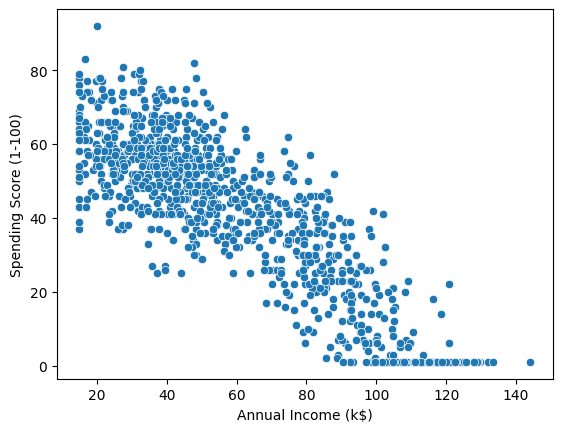

In [9]:
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", data=df)
plt.show()

In [17]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()
X.dtypes

Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object

# Applying K-Means Clustering

In [12]:
from sklearn.cluster import KMeans

In [16]:
df.head()
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [18]:
X.isnull().sum()

Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [19]:
X=X.dropna()

In [20]:
X.isnull().sum()

Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [21]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Finding Optimal Clusters using Elbow Method

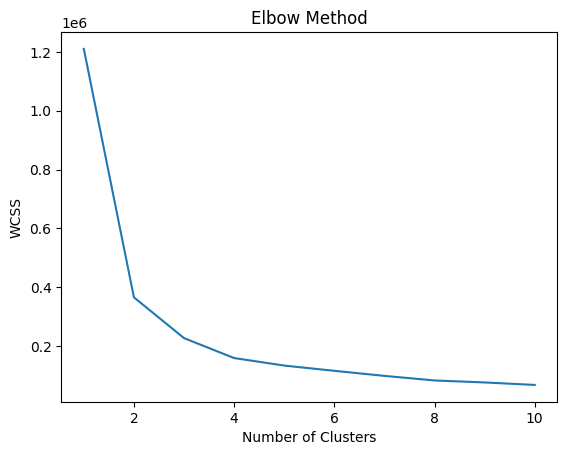

In [22]:
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [23]:
kmeans=KMeans(n_clusters=5,random_state=42)
y_kmeans=kmeans.fit_predict(X)

In [24]:
y_kmeans

array([1, 1, 0, 2, 1, 4, 2, 0, 1, 1, 4, 1, 1, 4, 4, 4, 1, 1, 4, 4, 2, 1,
       1, 1, 4, 1, 4, 1, 4, 1, 4, 2, 1, 4, 0, 1, 1, 4, 4, 1, 2, 0, 1, 4,
       4, 1, 4, 0, 1, 4, 1, 1, 1, 0, 0, 0, 4, 1, 1, 0, 4, 1, 4, 4, 0, 0,
       4, 0, 1, 4, 0, 2, 4, 2, 4, 1, 1, 1, 4, 4, 1, 1, 0, 1, 1, 4, 2, 0,
       4, 1, 1, 0, 1, 4, 1, 4, 1, 4, 1, 1, 4, 4, 4, 1, 1, 2, 0, 1, 1, 4,
       1, 1, 2, 1, 1, 1, 0, 0, 2, 4, 0, 4, 0, 3, 4, 4, 1, 4, 4, 1, 4, 1,
       1, 2, 1, 0, 0, 4, 1, 2, 4, 0, 4, 0, 4, 1, 0, 1, 1, 0, 4, 1, 1, 4,
       2, 1, 4, 2, 4, 0, 0, 4, 2, 1, 0, 2, 1, 4, 4, 4, 0, 0, 4, 0, 1, 2,
       1, 2, 0, 4, 4, 4, 4, 2, 1, 1, 4, 1, 2, 1, 4, 0, 1, 4, 4, 1, 4, 1,
       1, 0, 2, 4, 4, 1, 4, 1, 3, 0, 0, 1, 0, 1, 2, 4, 4, 1, 1, 2, 4, 1,
       4, 1, 2, 1, 4, 1, 0, 4, 1, 4, 4, 2, 0, 4, 4, 4, 0, 0, 4, 0, 2, 4,
       1, 4, 4, 0, 0, 4, 0, 2, 0, 4, 1, 0, 4, 1, 2, 4, 4, 4, 4, 1, 4, 0,
       4, 4, 1, 0, 4, 0, 4, 1, 0, 1, 4, 1, 1, 1, 2, 2, 4, 2, 1, 0, 1, 1,
       4, 4, 1, 0, 1, 4, 0, 1, 0, 0, 1, 1, 0, 0, 1,

# Cluster Analysis

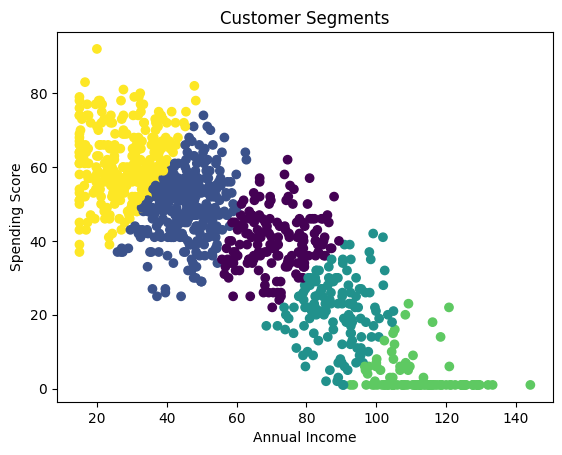

In [25]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans, cmap='viridis')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

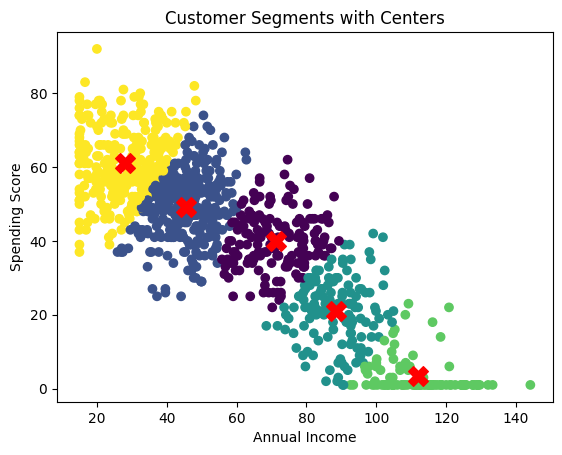

In [26]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            s=200, c='red', marker='X')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments with Centers")
plt.show()

In [28]:
df=df.dropna()

In [29]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [30]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

In [31]:
df["Cluster"] = y_kmeans
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1000,M,39.0,59.9,58.0,2
1,1001,M,34.0,48.4,37.0,2
2,1002,F,40.0,70.5,26.0,0
3,1003,F,47.0,81.1,30.0,0
4,1004,F,33.0,42.1,58.0,4


In [33]:
df["Cluster"].value_counts().sort_index()

Cluster
0    164
1    226
2    160
3    128
4    304
Name: count, dtype: int64

In [34]:
#cluster interpretation
cluster_profile = df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()

cluster_profile


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.359756,84.168293,28.231707
1,26.774336,26.509735,62.752212
2,38.962500,61.746250,42.218750
3,65.968750,108.168750,4.851562
4,32.648026,42.023355,51.476974


In [35]:
cluster_profile = cluster_profile.round(1)
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.4,84.2,28.2
1,26.8,26.5,62.8
2,39.0,61.7,42.2
3,66.0,108.2,4.9
4,32.6,42.0,51.5


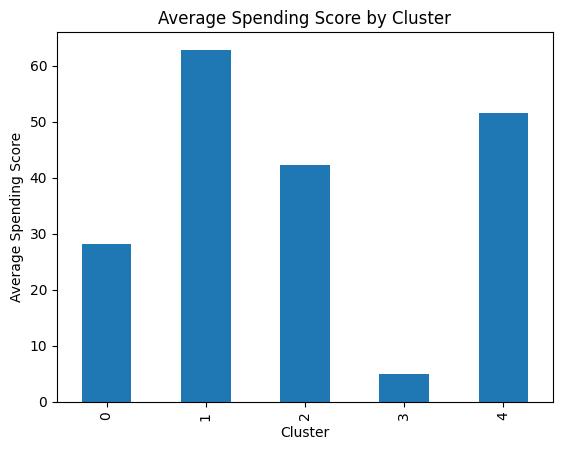

In [36]:
import matplotlib.pyplot as plt

cluster_profile['Spending Score (1-100)'].plot(kind='bar')

plt.title("Average Spending Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Spending Score")
plt.show()

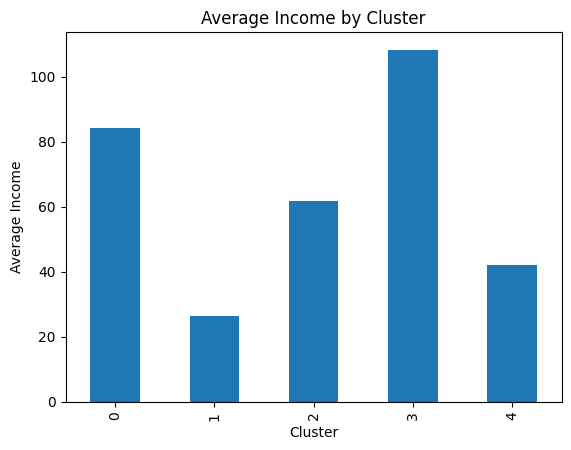

In [37]:
cluster_profile['Annual Income (k$)'].plot(kind='bar')

plt.title("Average Income by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Income")
plt.show()

In [38]:
cluster_names = {
    0: "High Income Low Spenders",
    1: "Low Income High Spenders",
    2: "Average Customers",
    3: "Very Rich Low Spenders",
    4: "Active Shoppers"
}

df["Customer Segment"] = df["Cluster"].map(cluster_names)

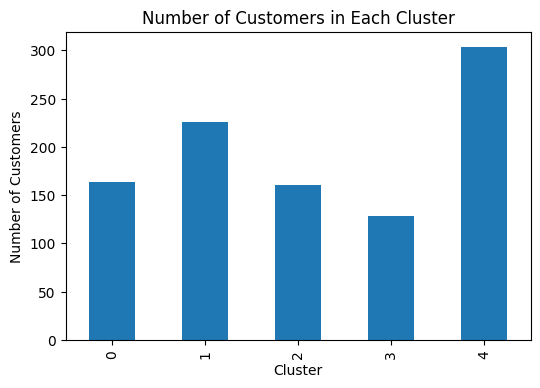

In [39]:
cluster_counts = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(6,4))
cluster_counts.plot(kind='bar')

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [40]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1000,M,39.0,59.9,58.0,2,Average Customers
1,1001,M,34.0,48.4,37.0,2,Average Customers
2,1002,F,40.0,70.5,26.0,0,High Income Low Spenders
3,1003,F,47.0,81.1,30.0,0,High Income Low Spenders
4,1004,F,33.0,42.1,58.0,4,Active Shoppers


In [41]:
df.to_csv("segmented_customers.csv", index=False)